In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\DEV\dp_312\.venv\Scripts\python.exe -m pip install --upgrade pip


In [3]:
# 1. 라이브러리 불러오기 및 실습 데이터 생성
# 데이터 탐색과 함께 간단한 시각화까지 요약해서 확인할 수 있도록 matplotlib과 seaborn 라이브러리를 함께 사용합니다.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 시각화 한글 깨짐 방지 설정 (윈도우 기준, 맥은 'AppleGothic')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 실습용 가상 고객 데이터 생성
np.random.seed(42)
data = {
    '고객ID': [f'C{i:03d}' for i in range(1, 101)],
    '나이': np.random.randint(20, 60, size=100),
    '성별': np.random.choice(['남', '여'], size=100, p=[0.45, 0.55]),
    '구매금액': np.random.exponential(scale=200000, size=100).astype(int) + 10000,
    '가입기간(월)': np.random.randint(1, 48, size=100),
    '등급': np.random.choice(['Bronze', 'Silver', 'Gold'], size=100, p=[0.5, 0.3, 0.2])
}

df = pd.DataFrame(data)
# 인위적으로 결측치 5개 삽입
df.loc[np.random.choice(100, 5, replace=False), '나이'] = np.nan

In [4]:
# 2. 데이터 구조 및 타입 확인
# 데이터를 받자마자 가장 먼저 실행해야 하는 필수 데이터 탐색 명령어 스리콤보(head, info, shape)입니다.

print("--- 1. 데이터 상위 5개 행 확인 ---")
print(df.head())
print("\n" + "="*50 + "\n")

print("--- 2. 데이터 구조 및 행/열 개수 확인 ---")
print(f"데이터 형태(Shape): {df.shape}  -> {df.shape[0]}행, {df.shape[1]}열")
print("\n" + "="*50 + "\n")

print("--- 3. 컬럼 정보 및 데이터 타입 확인 ---")
df.info()

--- 1. 데이터 상위 5개 행 확인 ---
   고객ID    나이 성별    구매금액  가입기간(월)      등급
0  C001  58.0  남  429666        2  Silver
1  C002  48.0  남   69665       32  Silver
2  C003  34.0  남  225752       23  Bronze
3  C004   NaN  여  349896       22    Gold
4  C005  40.0  여  172026       25    Gold


--- 2. 데이터 구조 및 행/열 개수 확인 ---
데이터 형태(Shape): (100, 6)  -> 100행, 6열


--- 3. 컬럼 정보 및 데이터 타입 확인 ---
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   고객ID     100 non-null    str    
 1   나이       95 non-null     float64
 2   성별       100 non-null    str    
 3   구매금액     100 non-null    int64  
 4   가입기간(월)  100 non-null    int32  
 5   등급       100 non-null    str    
dtypes: float64(1), int32(1), int64(1), str(3)
memory usage: 4.4 KB


In [5]:
# 3. 요약 통계량 확인 (Describe)
# 수치형 데이터의 중심 경향성(평균, 중앙값)과 퍼짐 정도(표준편차, 사분위수)를 한눈에 파악합니다.

print("--- 1. 수치형 컬럼의 요약 통계 ---")
# mean(평균)과 50%(중앙값)의 차이가 클 경우, 데이터가 한쪽으로 치우쳤음을 짐작할 수 있습니다.
print(df.describe())
print("\n" + "="*50 + "\n")

print("--- 2. 범주형(문자열) 컬럼의 요약 통계 ---")
# unique(고유값 개수), top(최빈값), freq(최빈값의 빈도)를 보여줍니다.
print(df.describe(include=['object']))


--- 1. 수치형 컬럼의 요약 통계 ---
              나이           구매금액     가입기간(월)
count  95.000000     100.000000  100.000000
mean   38.936842  238019.700000   23.970000
std    11.666291  188099.597638   13.401685
min    20.000000   11014.000000    1.000000
25%    28.000000   88101.750000   13.750000
50%    40.000000  205186.000000   25.000000
75%    47.500000  341671.750000   34.000000
max    59.000000  932113.000000   47.000000


--- 2. 범주형(문자열) 컬럼의 요약 통계 ---
        고객ID   성별      등급
count    100  100     100
unique   100    2       3
top     C001    여  Bronze
freq       1   51      47


C:\Users\kz4ne\AppData\Local\Temp\ipykernel_24016\1761064909.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['object']))


In [6]:
# 4. 값의 분포 및 빈도 확인 (Value Counts)
# 범주형 데이터나 개수가 정해진 수치형 데이터의 클래스별 비율을 확인합니다.

print("--- 1. 등급별 고객 수 ---")
print(df['등급'].value_counts())
print("\n" + "="*50 + "\n")

print("--- 2. 성별 비율 확인 (normalize=True) ---")
print(df['성별'].value_counts(normalize=True) * 100)

--- 1. 등급별 고객 수 ---
등급
Bronze    47
Silver    32
Gold      21
Name: count, dtype: int64


--- 2. 성별 비율 확인 (normalize=True) ---
성별
여    51.0
남    49.0
Name: proportion, dtype: float64


In [7]:
# 5. 그룹별 통계 분석 (Aggregation)
# 특정 범주(성별, 등급 등)에 따라 수치형 데이터가 어떻게 달라지는지 교차 분석합니다.

print("--- 1. 등급별 평균 구매금액과 나이 ---")
# 등급으로 묶은 후, 각각 구매금액과 나이의 평균을 계산합니다.
print(df.groupby('등급')[['구매금액', '나이']].mean())
print("\n" + "="*50 + "\n")

print("--- 2. 성별 및 등급별 복합 당 통계 (agg) ---")
# 성별과 등급을 기준으로 구매금액의 '총합'과 '평균'을 동시에 구합니다.
print(df.groupby(['성별', '등급'])['구매금액'].agg(['sum', 'mean']))

--- 1. 등급별 평균 구매금액과 나이 ---
                 구매금액         나이
등급                              
Bronze  239384.446809  36.934783
Gold    258863.190476  40.000000
Silver  222336.687500  41.333333


--- 2. 성별 및 등급별 복합 당 통계 (agg) ---
               sum           mean
성별 등급                            
남  Bronze  6314653  263110.541667
   Gold    1857402  206378.000000
   Silver  3384699  211543.687500
여  Bronze  4936416  214626.782609
   Gold    3578725  298227.083333
   Silver  3730075  233129.687500


In [8]:
# 6. 변수 간의 상관관계 탐색 (Correlation)
# 수치형 변수들끼리 서로 얼마나 밀접한 관계를 맺고 있는지 상관계수(Correlation Coefficient)를 구합니다.

print("--- 수치형 변수 간 상관계수 행렬 ---")
# 1에 가까울수록 양의 상관관계, -1에 가까울수록 음의 상관관계입니다.
numeric_cols = ['나이', '구매금액', '가입기간(월)']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

--- 수치형 변수 간 상관계수 행렬 ---
               나이      구매금액   가입기간(월)
나이       1.000000 -0.100412 -0.066965
구매금액    -0.100412  1.000000  0.178002
가입기간(월) -0.066965  0.178002  1.000000


C:\Users\kz4ne\AppData\Local\Temp\ipykernel_24016\2124802375.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='등급', data=df, order=['Bronze', 'Silver', 'Gold'], ax=axes[0, 1], palette='Set2')


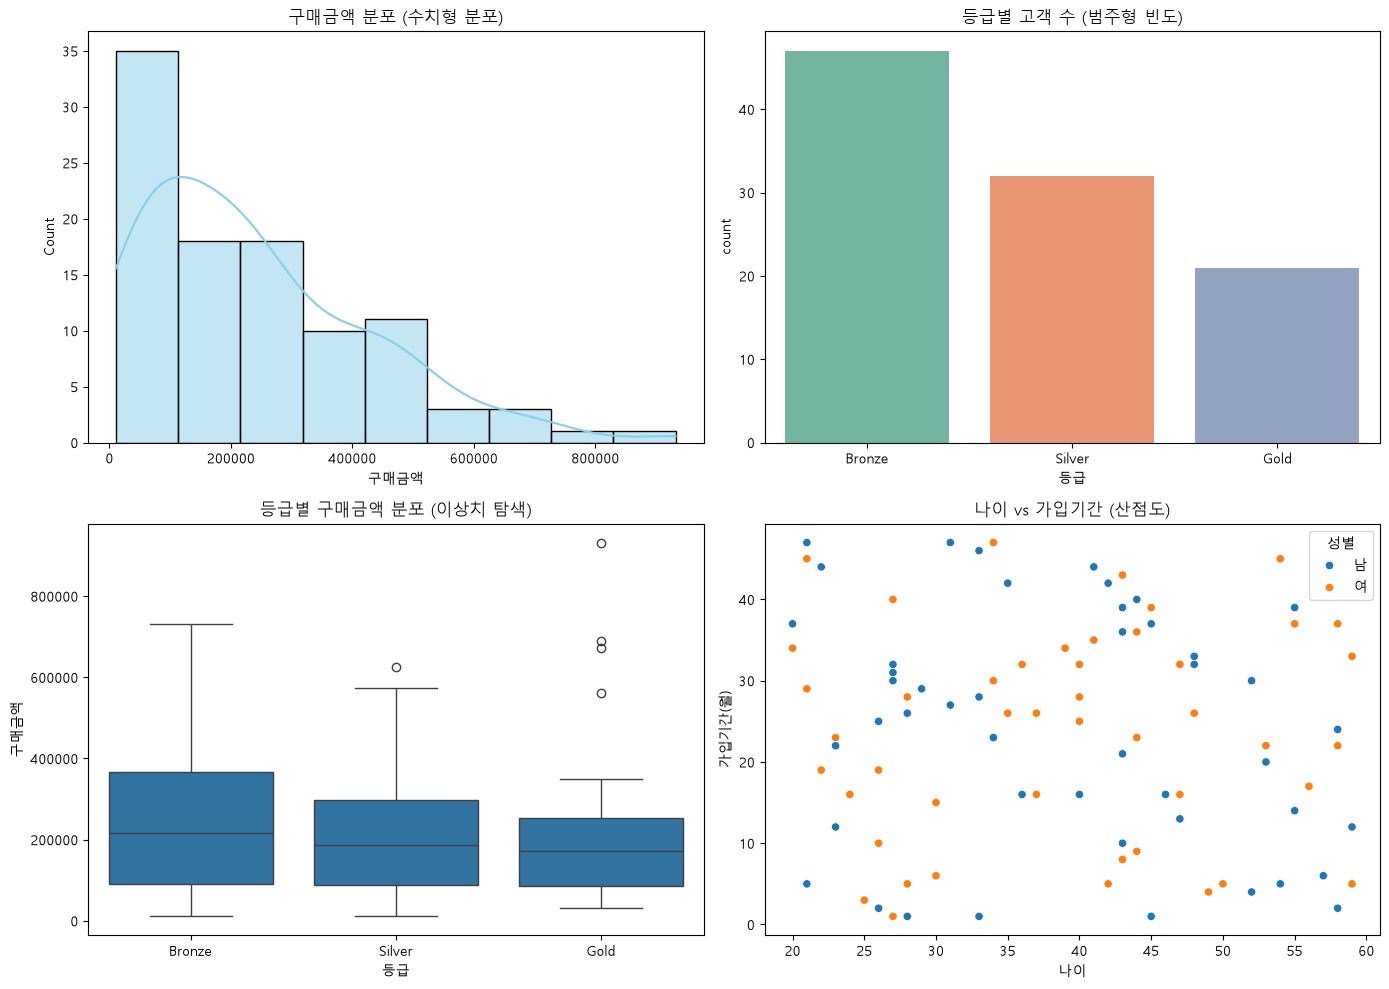

In [9]:
# 7. EDA 기초 시각화
# 수치와 텍스트로만 보던 데이터를 차트로 시각화하여 왜곡(Outlier)이나 분포 형태를 직관적으로 파악합니다.

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# [시각화 1] 구매금액 분포 (Histogram) - 한쪽으로 치우친 데이터 확인
sns.histplot(df['구매금액'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('구매금액 분포 (수치형 분포)')

# [시각화 2] 등급별 고객 수 (Countplot) - 범주형 빈도 확인
sns.countplot(x='등급', data=df, order=['Bronze', 'Silver', 'Gold'], ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('등급별 고객 수 (범주형 빈도)')

# [시각화 3] 등급별 구매금액 상자 그림 (Boxplot) - 이상치(Outlier) 발견용
sns.boxplot(x='등급', y='구매금액', data=df, order=['Bronze', 'Silver', 'Gold'], ax=axes[1, 0])
axes[1, 0].set_title('등급별 구매금액 분포 (이상치 탐색)')

# [시각화 4] 나이와 가입기간의 관계 (Scatterplot) - 두 변수 간 관계
sns.scatterplot(x='나이', y='가입기간(월)', hue='성별', data=df, ax=axes[1, 1])
axes[1, 1].set_title('나이 vs 가입기간 (산점도)')

plt.tight_layout()
plt.show()